<a href="https://colab.research.google.com/github/Pradss789/Wine-Quality-Classification/blob/main/Classification_using_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PREDIKSI KUALITAS ANGGUR**

##Dataset
Dataset yang digunakan adalah dataset kualitas anggur merah dan putih yang terdiri dari:

*   `data_training.csv` yang berisi data dengan label kualitas, digunakan untuk melatih model
*   `data_testing.csv` yang berisi data tanpa label kualitas, digunakan untuk prediksi akhir

Variabel target adalah **`quality`** (skala 0 - 10), dengan fitur input 11 variabel kimiawi (fixed acidity, volatile acidity, citric acid, dll.)




##1. Import Library
Impor semua library yang dibutuhkan:


*   **pandas & numpy** untuk manipulasi dan analisis data
*   **matplotlib & seaborn** untuk visualisasi data
*   **scikit-learn** untuk preprocessing, pembuatan model, dan evaluasi





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
# Pengaturan tampilan
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


##2. Persiapan Data

###2.1 Memuat dataset
Memuat dataset training dan testing dengan `pd.read_csv()`

In [2]:
# Memuat dataset
train = pd.read_csv('data_training.csv')
test  = pd.read_csv('data_testing.csv')

print(f"Ukuran data training : {train.shape[0]} baris × {train.shape[1]} kolom")
print(f"Ukuran data testing  : {test.shape[0]} baris × {test.shape[1]} kolom")

Ukuran data training : 857 baris × 13 kolom
Ukuran data testing  : 286 baris × 12 kolom


###2.2 Preview dan Informasi Tipe Data

In [3]:
print("=== Preview Data Training ===")
train.head()

=== Preview Data Training ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3000,0.7400,0.0800,1.7000,0.0940,10.0000,45.0000,0.9958,3.2400,0.5000,9.8000,5,1366
1,8.1000,0.5750,0.2200,2.1000,0.0770,12.0000,65.0000,0.9967,3.2900,0.5100,9.2000,5,103
2,10.1000,0.4300,0.4000,2.6000,0.0920,13.0000,52.0000,0.9983,3.2200,0.6400,10.0000,7,942
3,12.9000,0.5000,0.5500,2.8000,0.0720,7.0000,24.0000,1.0001,3.0900,0.6800,10.9000,6,811
4,8.4000,0.3600,0.3200,2.2000,0.0810,32.0000,79.0000,0.9964,3.3000,0.7200,11.0000,6,918


In [4]:
print("=== Preview Data Testing ===")
test.head()

=== Preview Data Testing ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8000,0.6100,0.0400,1.5000,0.0570,5.0000,10.0000,0.9952,3.4200,0.6000,9.5000,222
1,6.9000,0.8400,0.2100,4.1000,0.0740,16.0000,65.0000,0.9984,3.5300,0.7200,9.2333,1514
2,7.0000,0.5800,0.1200,1.9000,0.0910,34.0000,124.0000,0.9956,3.4400,0.4800,10.5000,417
3,7.8000,0.4800,0.6800,1.7000,0.4150,14.0000,32.0000,0.9966,3.0900,1.0600,9.1000,754
4,12.5000,0.6000,0.4900,4.3000,0.1000,5.0000,14.0000,1.0010,3.2500,0.7400,11.9000,516


In [5]:
print("=== Informasi Data Training ===")
train.info()

=== Informasi Data Training ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


##3. Pembersihan Data (Data Cleaning)

###3.1 Pengecekan Missing Values
Missing value (nilai yang hilang) dapat mengganggu proses pelatihan model.
Kita perlu memastikan tidak ada nilai kosong sebelum melanjutkan ke tahap berikutnya.

In [6]:
print("=== Missing Values pada Data Training ===")
mv_train = train.isnull().sum()
print(mv_train[mv_train > 0] if mv_train.any() else "Tidak ada missing values pada data training.")

print()
print("=== Missing Values pada Data Testing ===")
mv_test = test.isnull().sum()
print(mv_test[mv_test > 0] if mv_test.any() else "Tidak ada missing values pada data testing.")

=== Missing Values pada Data Training ===
Tidak ada missing values pada data training.

=== Missing Values pada Data Testing ===
Tidak ada missing values pada data testing.


###**Interpretasi**
Kedua dataset tidak memiliki missing values, sehingga tidak diperlukan proses imputasi maupun penghapusan data. Dataset siap digunakan untuk analisis lebih lanjut.

###3.2 Statistik Deskriptif

In [7]:
print("=== Statistik Deskriptif Data Training ===")
train.describe()

=== Statistik Deskriptif Data Training ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000
mean,8.2620,0.5294,0.2674,2.5062,0.0868,15.7830,45.9784,0.9967,3.3131,0.6567,10.4303,5.6534,813.7491
std,1.7020,0.1792,0.1951,1.2935,0.0487,10.3004,31.6921,0.0019,0.1521,0.1674,1.0670,0.8218,463.8071
min,4.6000,0.1200,0.0000,0.9000,0.0120,1.0000,6.0000,0.9901,2.7400,0.3900,8.4000,3.0000,0.0000
25%,7.1000,0.3950,0.0900,1.9000,0.0700,7.0000,21.0000,0.9955,3.2100,0.5500,9.5000,5.0000,413.0000
50%,7.9000,0.5200,0.2500,2.2000,0.0790,14.0000,38.0000,0.9967,3.3100,0.6200,10.2000,6.0000,814.0000
75%,9.1000,0.6400,0.4200,2.6000,0.0900,21.0000,63.0000,0.9978,3.4000,0.7300,11.1000,6.0000,1214.0000
max,15.6000,1.5800,1.0000,15.5000,0.6110,68.0000,278.0000,1.0032,4.0100,2.0000,14.0000,8.0000,1597.0000


###**Interpretasi**

Terdapat beberapa fitur yang memiliki skala yang sangat berbeda, misalnya `residual sugar` bisa mencapai nilai puluhan, sedangkan `chlorides` hanya 0.0 - 0.6. Perbedaan skala ini dapat memengaruhi performa model berbasis jarak. Oleh karena itu, **feature scaling** (normalisasi) akan diterapkan pada tahap preprocessing.

Terdapat beberapa fitur yang memiliki nilai ekstrem (outlier) yang terlihat dari perbedaan besar antara mean dan nilai maksimum.



##4. Eksplorasi Data (EDA)
EDA bertujuan untuk memahami karakteristik data sebelum membangun model, meliputi:
- Distribusi variabel target
- Korelasi antar fitur
- Hubungan fitur dengan kualitas anggur

###4.1 Distribusi Variabel Target (`quality`)

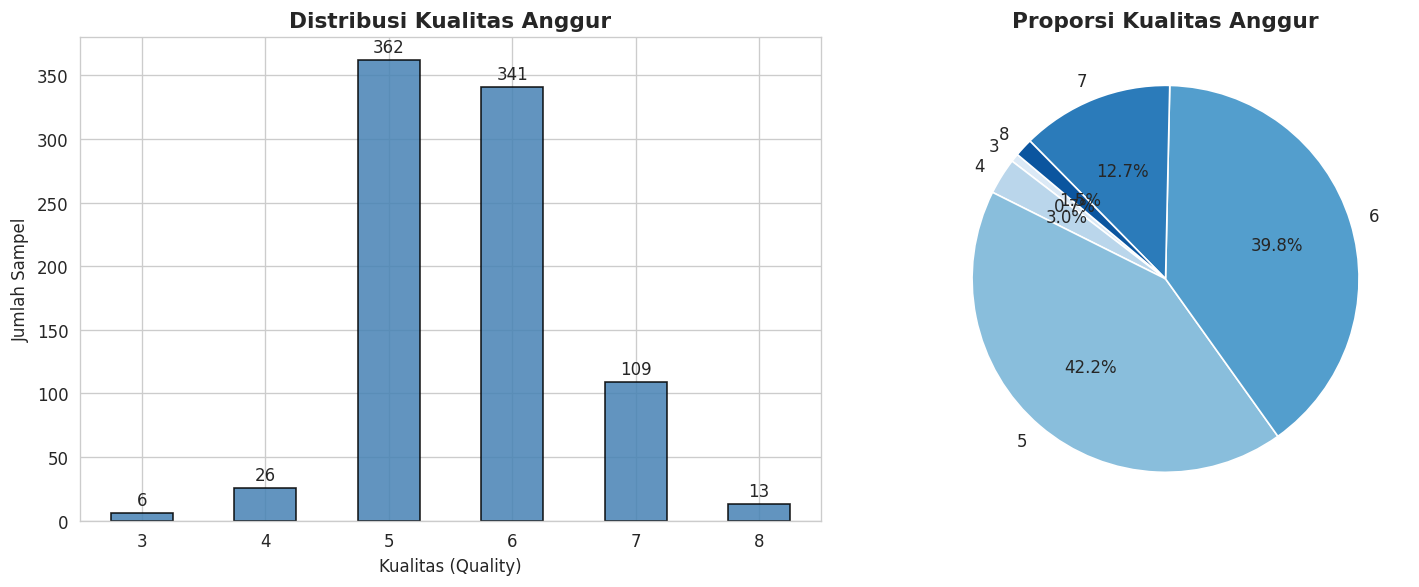

Distribusi kualitas:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


In [8]:
quality_counts = train['quality'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar plot
quality_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Kualitas Anggur', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kualitas (Quality)')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, quality_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(quality_counts, labels=quality_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Blues', len(quality_counts)))
axes[1].set_title('Proporsi Kualitas Anggur', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_kualitas.png', bbox_inches='tight')
plt.show()

print("Distribusi kualitas:")
print(quality_counts)

###**Interpretasi**  
Dataset memiliki distribusi kelas yang **tidak seimbang (imbalanced)** terlihat dari visualisasi **Pie Chart** mayoritas sampel berkulitas **5** (42.2%) dan **6** (39.8%), dan pada kelas ekstrem (3 dan 8) sangat sedikit yaitu masing-masing hanya ~0.7% dan ~1.5%.

Ketidakseimbangan ini merupakan tantangan dalam klasifikasi, karena model cenderung lebih "mengenal" kelas mayoritas. Namun, Random Forest cukup robust terhadap kondisi ini.

###4.2 Heatmap Korelasi Antar Fitur

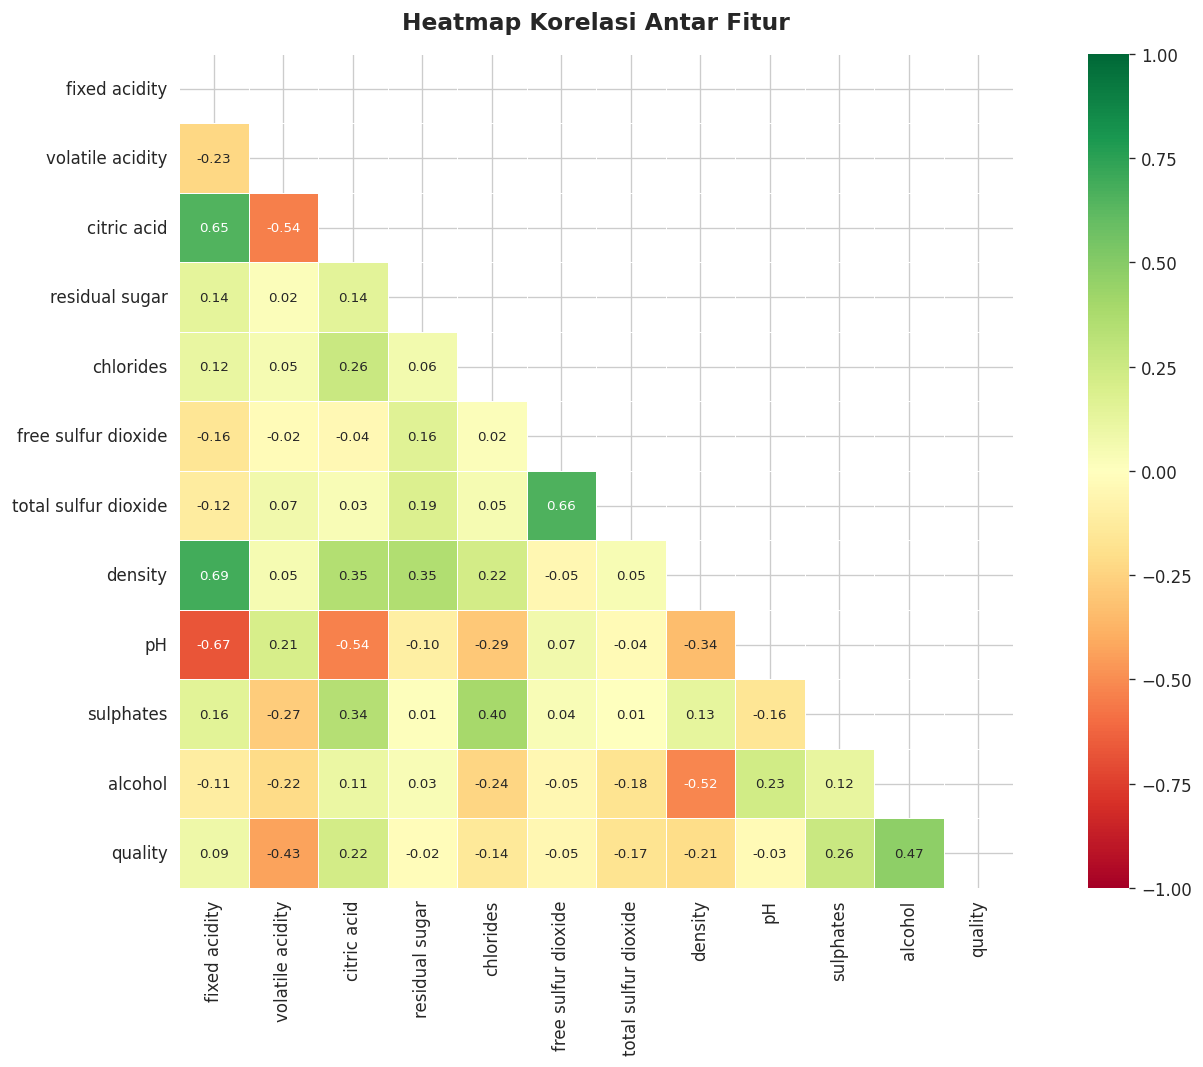

=== Korelasi Fitur dengan Quality (diurutkan) ===
alcohol                 0.4736
sulphates               0.2607
citric acid             0.2213
fixed acidity           0.0927
residual sugar         -0.0205
pH                     -0.0332
free sulfur dioxide    -0.0545
chlorides              -0.1449
total sulfur dioxide   -0.1727
density                -0.2079
volatile acidity       -0.4301


In [9]:
feature_cols = [c for c in test.columns if c != 'Id']
corr_matrix = train[feature_cols + ['quality']].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.4, annot_kws={'size': 8},
            vmin=-1, vmax=1, square=True)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', bbox_inches='tight')
plt.show()

print("=== Korelasi Fitur dengan Quality (diurutkan) ===")
print(corr_matrix['quality'].drop('quality').sort_values(ascending=False).to_string())

###**Interpretasi:**

*   **`alcohol`** memiliki korelasi positif tertinggi dengan quality (≈ +0.48) artinya semakin tinggi kadar alkohol, cenderung semakin tinggi kualitasnya.
*   **`volatile acidity`** memiliki korelasi negatif terkuat (≈ −0.39) ini menunjukkan keasaman volatil yang tinggi menurunkan kualitas anggur.
*   **`sulphates`** berkorelasi positif (≈ +0.25) berarti sulfit berfungsi sebagai pengawet dan dapat meningkatkan kualitas.
*   **`density`** dan **`fixed acidity`** berkorelasi tinggi satu sama lain ini mengindikasikan potensi multikolinearitas, tetapi Random Forest tidak terpengaruh oleh hal ini.



###4.3 Distribusi Fitur Berdasarkan Kualitas

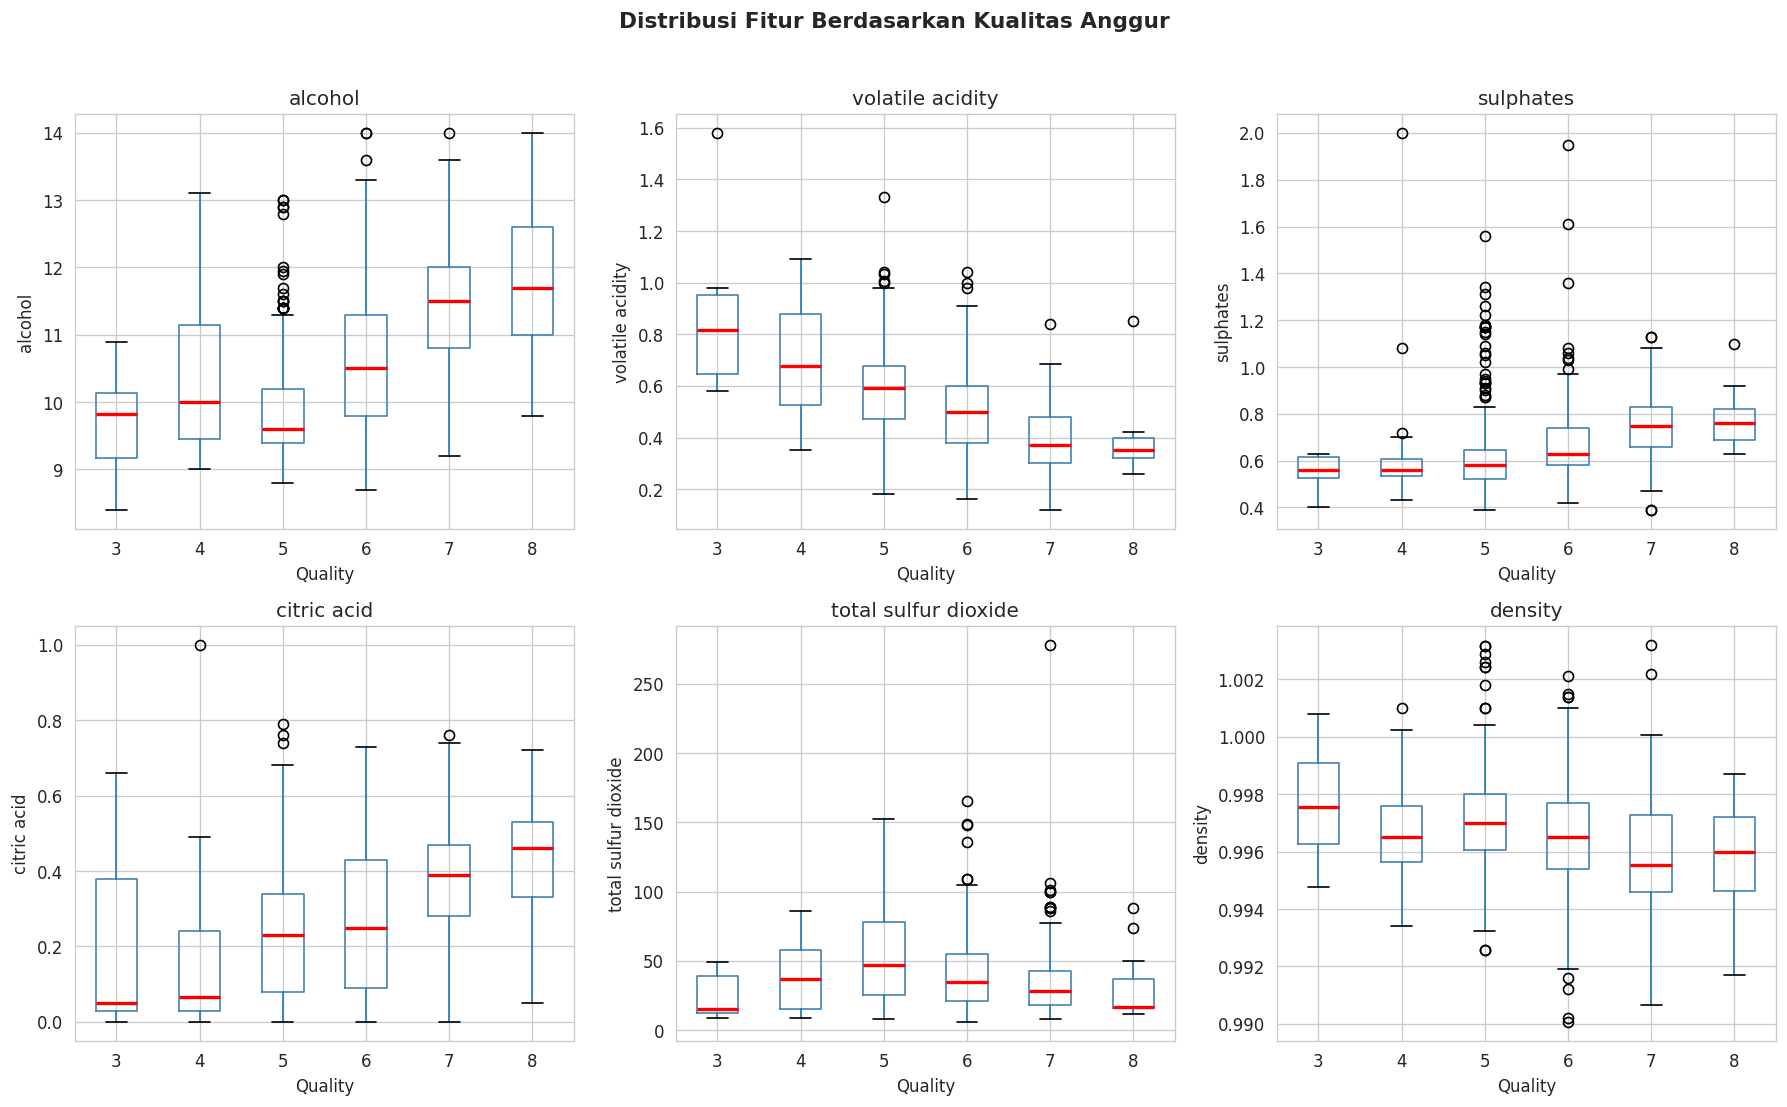

In [10]:
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid',
                 'total sulfur dioxide', 'density']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    train.boxplot(column=feat, by='quality', ax=axes[i],
                  boxprops=dict(color='steelblue'),
                  medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{feat}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel(feat)
    plt.sca(axes[i])
    plt.title(feat)

plt.suptitle('Distribusi Fitur Berdasarkan Kualitas Anggur', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplot_fitur.png', bbox_inches='tight')
plt.show()

###**Interpretasi:**
*   **Alcohol**: Tren yang jelas terlihat anggur dengan kualitas tinggi (7 - 8) cenderung memiliki kadar alkohol lebih tinggi.
*   **Volatile Acidity**: Anggur berkualitas rendah memiliki **volatile acidity** lebih tinggi, pola ini konsisten dan dapat menjadi diskriminator yang baik.
*   **Sulphates**: Anggur berkualitas tinggi cenderung memiliki kadar sulphates yang lebih tinggi.
*   **Total Sulfur Dioxide**: Lebih sulit dibedakan antar kelas, namun masih memberikan informasi parsial.




##5. Pembuatan Model Klasifikasi
###5.1 Pemilihan Model: Random Forest Classifier
Model Random Forest dipilih sebagai algoritma klasifikasi karena memiliki performa yang baik pada data tabular dan mampu menangani hubungan non-linear antar fitur. Selain itu, Random Forest bersifat lebih robust terhadap variasi data dibandingkan model klasifikasi sederhana. Algoritma ini juga dapat menampilkan tingkat pentingnya masing-masing fitur (feature importance) sehingga membantu proses interpretasi model. Keunggulan lainnya adalah Random Forest tidak memerlukan asumsi distribusi data tertentu.
###5.2 Feature Scaling
Meskipun Random Forest tidak sensitif terhadap skala, StandardScaler tetap diterapkan sebagai praktik yang baik dan memastikan konsistensi jika model lain dibandingkan.

In [11]:
# Memisahkan fitur dan target
feature_cols = [c for c in test.columns if c != 'Id']
X = train[feature_cols]
y = train['quality']
X_test_raw = test[feature_cols]

# Feature Scaling
scaler = StandardScaler()
X_scaled      = scaler.fit_transform(X)        # fit + transform pada training
X_test_scaled = scaler.transform(X_test_raw)   # hanya transform pada testing (tanpa fit ulang)

print(f"Jumlah fitur : {len(feature_cols)}")
print(f"Fitur yang digunakan:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")
print()
print("Feature scaling telah dilakukan.")
print("Mean setiap fitur setelah scaling (seharusnya ≈ 0):")
print(np.round(X_scaled.mean(axis=0), 4))

Jumlah fitur : 11
Fitur yang digunakan:
   1. fixed acidity
   2. volatile acidity
   3. citric acid
   4. residual sugar
   5. chlorides
   6. free sulfur dioxide
   7. total sulfur dioxide
   8. density
   9. pH
  10. sulphates
  11. alcohol

Feature scaling telah dilakukan.
Mean setiap fitur setelah scaling (seharusnya ≈ 0):
[ 0. -0.  0. -0.  0.  0. -0.  0.  0. -0.  0.]


**Catatan:** `scaler.fit_transform()` hanya dipanggil pada data training. Data testing hanya menggunakan `scaler.transform()` (tanpa `fit`) untuk menghindari **data leakage** yaitu kondisi di mana informasi dari data testing "bocor" ke proses training.


###5.3 Evaluasi Model dengan Cross-Validation (5-Fold)
Cross-validation digunakan untuk mendapatkan estimasi performa yang lebih andal daripada sekadar train-test split biasa. Dataset dibagi menjadi 5 bagian (*fold*), dengan cara model dilatih pada 4 bagian dan diuji pada 1 bagian, diulang sebanyak 5 kali.

In [12]:
rf = RandomForestClassifier(
    n_estimators  = 300,   # jumlah pohon keputusan
    max_depth     = None,  # kedalaman pohon tidak dibatasi
    min_samples_split = 2,
    random_state  = 42,
    n_jobs        = -1     # gunakan semua core CPU
)

cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')

print("=== Hasil Cross-Validation (5-Fold) ===")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}  ({s*100:.2f}%)")
print(f"\n{'Akurasi Rata-rata':<25}: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"{'Standar Deviasi':<25}: {cv_scores.std():.4f}")

=== Hasil Cross-Validation (5-Fold) ===
  Fold 1: 0.6570  (65.70%)
  Fold 2: 0.6570  (65.70%)
  Fold 3: 0.6725  (67.25%)
  Fold 4: 0.6608  (66.08%)
  Fold 5: 0.5556  (55.56%)

Akurasi Rata-rata        : 0.6406 (64.06%)
Standar Deviasi          : 0.0429


###**Interpretasi**
Akurasi rata-rata cross-validation sekitar **64%**. Nilai ini wajar untuk kasus ini karena terdapat **6 kelas** (kualitas 3–8) yang harus dibedakan, dan distribusi kelas sangat **tidak seimbang** dari kelas 3 dan 8 memiliki sangat sedikit sampel, juga perbedaan antar kelas yang berdekatan (misal kualitas 5 vs 6) memang secara kimiawi sangat tipis

Standar deviasi yang kecil (±0.04) menunjukkan model **konsisten** dan tidak overfit pada fold tertentu.


### 5.4 Evaluasi Lebih Detail: Train-Validation Split

Untuk mendapatkan classification report dan confusion matrix, kita lakukan train-validation split dengan proporsi 80:20.

In [13]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

rf.fit(X_tr, y_tr)
y_pred_val = rf.predict(X_val)

print("=== Evaluasi pada Validation Set (80:20 split) ===")
print(f"Akurasi: {accuracy_score(y_val, y_pred_val):.4f} ({accuracy_score(y_val, y_pred_val)*100:.2f}%)\n")
print("=== Classification Report ===")
print(classification_report(y_val, y_pred_val))

=== Evaluasi pada Validation Set (80:20 split) ===
Akurasi: 0.5988 (59.88%)

=== Classification Report ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.78      0.71        73
           6       0.55      0.57      0.56        68
           7       0.46      0.27      0.34        22
           8       1.00      0.33      0.50         3

    accuracy                           0.60       172
   macro avg       0.44      0.33      0.35       172
weighted avg       0.57      0.60      0.58       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###**Interpretasi Classification Report:**
- **Precision**: Dari semua prediksi kelas X, berapa persen yang benar
- **Recall**: Dari semua data kelas X yang sebenarnya, berapa persen yang terdeteksi
- **F1-score**: Harmonic mean antara precision dan recall

Kelas 5 dan 6 memiliki performa terbaik karena jumlah sampelnya banyak. Kelas 3, 4, dan 8 memiliki F1-score rendah karena jumlah sampelnya sangat sedikit sehingga model sulit mempelajari polanya.

###5.5 Confusion Matrix

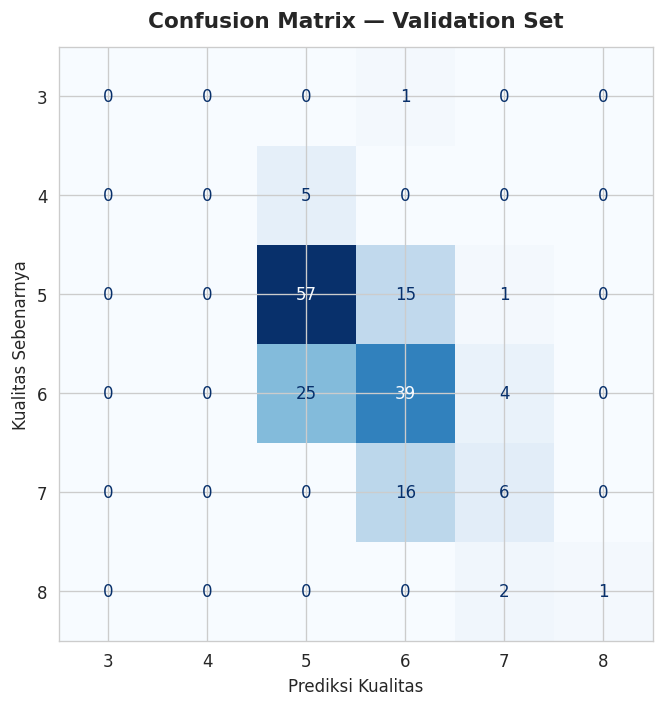

In [14]:
cm = confusion_matrix(y_val, y_pred_val)
labels = sorted(y.unique())

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Prediksi Kualitas')
plt.ylabel('Kualitas Sebenarnya')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

###**Interpretasi**
Sebagian besar kesalahan prediksi terjadi antara kelas yang berdekatan (misalnya memprediksi kualitas 5 padahal sebenarnya 6, atau sebaliknya). Hal ini sangat wajar karena perbedaan kimiawi antar kelas yang bersebelahan memang sangat tipis.

### 5.6 Feature Importance

Random Forest dapat mengukur seberapa besar kontribusi setiap fitur dalam pengambilan keputusan model.

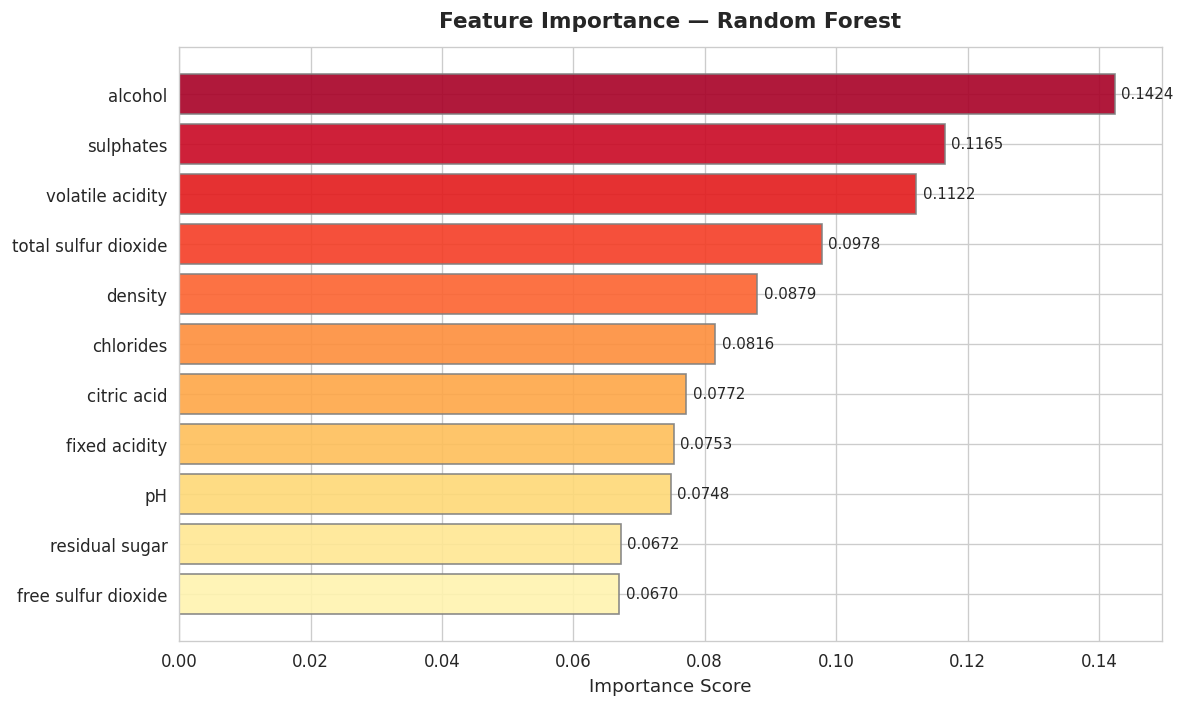

=== Peringkat Feature Importance ===
   1. alcohol                   : 0.1424 (14.24%)
   2. sulphates                 : 0.1165 (11.65%)
   3. volatile acidity          : 0.1122 (11.22%)
   4. total sulfur dioxide      : 0.0978 (9.78%)
   5. density                   : 0.0879 (8.79%)
   6. chlorides                 : 0.0816 (8.16%)
   7. citric acid               : 0.0772 (7.72%)
   8. fixed acidity             : 0.0753 (7.53%)
   9. pH                        : 0.0748 (7.48%)
  10. residual sugar            : 0.0672 (6.72%)
  11. free sulfur dioxide       : 0.0670 (6.70%)


In [15]:
# Latih pada seluruh data training
rf.fit(X_scaled, y)

feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = sns.color_palette('YlOrRd_r', len(feat_imp))
bars = plt.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors[::-1], edgecolor='gray', alpha=0.9)
plt.xlabel('Importance Score', fontsize=11)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold', pad=12)
for bar, val in zip(bars, feat_imp.values[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("=== Peringkat Feature Importance ===")
for rank, (feat, imp) in enumerate(feat_imp.items(), 1):
    print(f"  {rank:2d}. {feat:<25} : {imp:.4f} ({imp*100:.2f}%)")

###**Interpretasi Feature Importance:**
1. **Alcohol** (~14%): Fitur paling berpengaruh. Kadar alkohol mencerminkan tingkat fermentasi dan secara langsung memengaruhi cita rasa.
2. **Sulphates** (~12%): Berfungsi sebagai pengawet antimikroba, juga kadar yang tepat meningkatkan kualitas.
3. **Volatile Acidity** (~11%): Asam asetat (cuka) yang berlebihan menghasilkan rasa tidak enak, dan sangat diskriminatif antar kelas.
4. **Total Sulfur Dioxide** (~10%): Berkaitan dengan pengawetan, jika terlalu tinggi dapat memberikan bau menyengat.
5. **Density** (~9%): Berkorelasi dengan gula dan alkohol, ini merupakan indikator komposisi anggur.

Informasi ini konsisten dengan temuan EDA sebelumnya bahwa `alcohol` dan `volatile acidity` memiliki korelasi tertinggi dengan kualitas.


##6. Prediksi Data Testing

Setelah model dievaluasi dan dinyatakan memadai, model dilatih menggunakan **seluruh data training** (bukan hanya 80%) untuk memaksimalkan informasi yang dipelajari. Kemudian model digunakan untuk memprediksi kualitas anggur pada data testing.


In [16]:
# Model sudah dilatih pada seluruh data training di langkah sebelumnya (rf.fit(X_scaled, y))
# Lakukan prediksi pada data testing
y_pred_test = rf.predict(X_test_scaled)

print("=== Distribusi Hasil Prediksi Data Testing ===")
pred_dist = pd.Series(y_pred_test, name='Jumlah').value_counts().sort_index()
pred_dist_pct = (pred_dist / len(y_pred_test) * 100).round(2)
summary = pd.DataFrame({'Jumlah': pred_dist, 'Persentase (%)': pred_dist_pct})
print(summary)
print(f"\nTotal data testing yang diprediksi: {len(y_pred_test)} sampel")

=== Distribusi Hasil Prediksi Data Testing ===
        Jumlah  Persentase (%)
Jumlah                        
5          132         46.1500
6          125         43.7100
7           29         10.1400

Total data testing yang diprediksi: 286 sampel


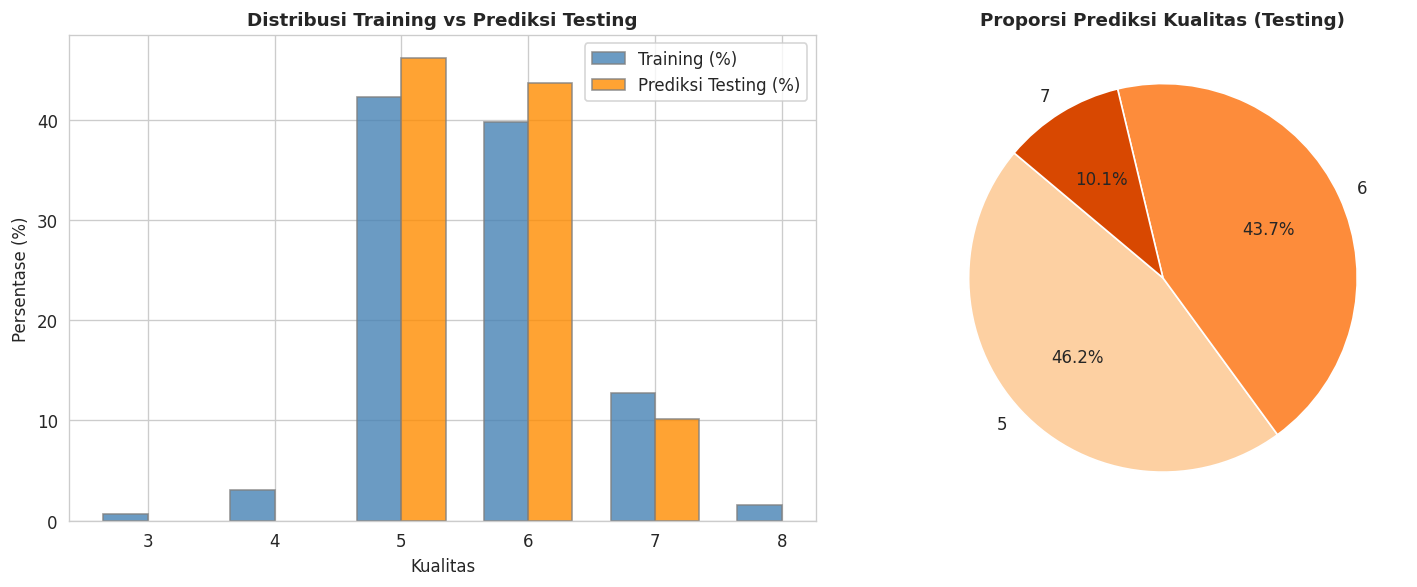

In [17]:
# Visualisasi distribusi prediksi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribusi prediksi vs training
width = 0.35
x = np.array(sorted(train['quality'].unique()))
train_pct = train['quality'].value_counts(normalize=True).sort_index() * 100
pred_counts = pd.Series(y_pred_test).value_counts().sort_index()
pred_pct = pred_counts / len(y_pred_test) * 100

x_pred = np.array(sorted(pred_counts.index))
axes[0].bar(x - width/2,
            [train_pct.get(q, 0) for q in x],
            width, label='Training (%)', color='steelblue', alpha=0.8, edgecolor='gray')
# Only plot prediction bars for classes that appear
axes[0].bar(x_pred + width/2,
            [pred_pct.get(q, 0) for q in x_pred],
            width, label='Prediksi Testing (%)', color='darkorange', alpha=0.8, edgecolor='gray')
axes[0].set_xlabel('Kualitas')
axes[0].set_ylabel('Persentase (%)')
axes[0].set_title('Distribusi Training vs Prediksi Testing', fontsize=11, fontweight='bold')
axes[0].legend()

# Pie chart prediksi
axes[1].pie(pred_counts, labels=pred_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Oranges', len(pred_counts)))
axes[1].set_title('Proporsi Prediksi Kualitas (Testing)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_prediksi.png', bbox_inches='tight')
plt.show()

###**Interpretasi**  
Distribusi prediksi pada data testing **konsisten** dengan distribusi data training. Mayoritas diprediksi berkualitas **5** dan **6** (~90%), sesuai dengan pola pada data training. Lalu, sebagian kecil diprediksi berkualitas **7**, yang juga proporsional.
Tidak ada prediksi kualitas 3 atau 8 (yang sangat langka), menunjukkan model tidak memaksakan prediksi kelas minoritas secara berlebihan.


##7. Menyimpan Hasil Prediksi




In [18]:
result = pd.DataFrame({
    'Id'     : test['Id'],
    'Quality': y_pred_test
})

output_filename = 'hasilprediksi_046.csv'
result.to_csv(output_filename, sep=';', index=False)

print(f"File hasil prediksi berhasil disimpan: '{output_filename}'")
print(f"Jumlah baris   : {len(result)}")
print(f"Kolom          : {list(result.columns)}")
print()
print("=== Preview 10 Hasil Prediksi Pertama ===")
print(result.head(10).to_string(index=False))

File hasil prediksi berhasil disimpan: 'hasilprediksi_046.csv'
Jumlah baris   : 286
Kolom          : ['Id', 'Quality']

=== Preview 10 Hasil Prediksi Pertama ===
  Id  Quality
 222        5
1514        6
 417        5
 754        5
 516        5
1120        6
 180        5
  82        5
 632        6
 592        5


##Kesimpulan

1. **Fitur paling berpengaruh** terhadap kualitas anggur adalah `alcohol`, `sulphates`, dan `volatile acidity`.

2. **Akurasi sekitar 64%** adalah hasil yang wajar untuk klasifikasi 6 kelas dengan distribusi yang sangat tidak seimbang. Sebagian besar kesalahan terjadi antara kelas yang bersebelahan (misalnya prediksi 5 vs aktual 6).

3. **Distribusi prediksi testing** konsisten dengan distribusi training, mengindikasikan model tidak mengalami overfitting parah.

4. **Random Forest** dipilih karena memberikan akurasi cross-validation tertinggi dibandingkan Gradient Boosting (60.9%) dan XGBoost (62.3%) pada dataset ini.